<a href="https://colab.research.google.com/github/Palash0306/credit-risk-scoring-engine/blob/develop/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install boto3 pandas numpy matplotlib seaborn scikit-learn \
             xgboost lightgbm dagshub mlflow pyarrow -q
print("Dependencies installed ✅")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/1

In [3]:
from google.colab import userdata
import os

# Load AWS credentials from Colab Secrets — never hardcoded
os.environ['AWS_ACCESS_KEY_ID']     = userdata.get('AWS_ACCESS_KEY_ID')
os.environ['AWS_SECRET_ACCESS_KEY'] = userdata.get('AWS_SECRET_ACCESS_KEY')
os.environ['AWS_DEFAULT_REGION']    = 'ap-south-1'
BUCKET = userdata.get('S3_BUCKET')

print("Credentials loaded ✅")

Credentials loaded ✅


In [4]:
import boto3
import pandas as pd
import io

# Read parquet directly from S3 into pandas
# Parquet preserves all data types — no casting needed
s3 = boto3.client('s3')
print("Reading fct_loans.parquet from S3...")

obj = s3.get_object(Bucket=BUCKET, Key='processed/fct_loans.parquet')
df = pd.read_parquet(io.BytesIO(obj['Body'].read()))

print(f"Loaded : {len(df):,} rows × {len(df.columns)} cols")
print(f"Train  : {df['is_train'].sum():,} rows")
print(f"Test   : {(~df['is_train']).sum():,} rows")
print(f"Default rate: {df['default_flag'].mean():.1%}")

Reading fct_loans.parquet from S3...
Loaded : 1,344,936 rows × 48 cols
Train  : 826,602 rows
Test   : 518,334 rows
Default rate: 20.0%


Class distribution:
  Fully Paid  (0): 1,076,448 — 80.0%
  Charged Off (1): 268,488 — 20.0%


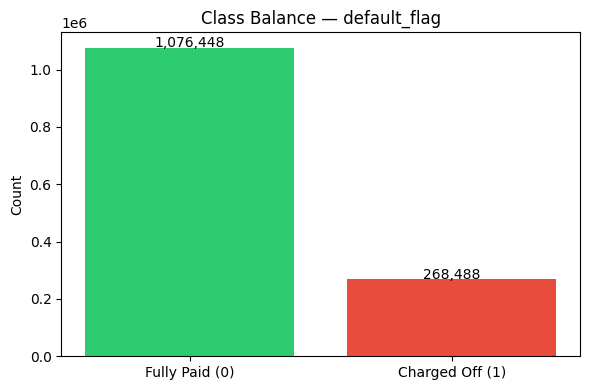

In [5]:
import matplotlib.pyplot as plt

# Class imbalance is critical in credit scoring
# If 80% of loans are Fully Paid, a model that always predicts 0
# would be 80% accurate but completely useless
# We need to understand the imbalance before training

class_counts = df['default_flag'].value_counts()
class_pct    = df['default_flag'].value_counts(normalize=True)

print("Class distribution:")
print(f"  Fully Paid  (0): {class_counts[0]:,} — {class_pct[0]:.1%}")
print(f"  Charged Off (1): {class_counts[1]:,} — {class_pct[1]:.1%}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Fully Paid (0)', 'Charged Off (1)'],
       class_counts.values,
       color=['#2ecc71', '#e74c3c'])
ax.set_title('Class Balance — default_flag')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

Default rate by grade:
grade  count  default_rate
    A 235054      0.060412
    B 392650      0.133862
    C 381550      0.224395
    D 200887      0.303833
    E  93622      0.384845
    F  32047      0.452055
    G   9126      0.499233


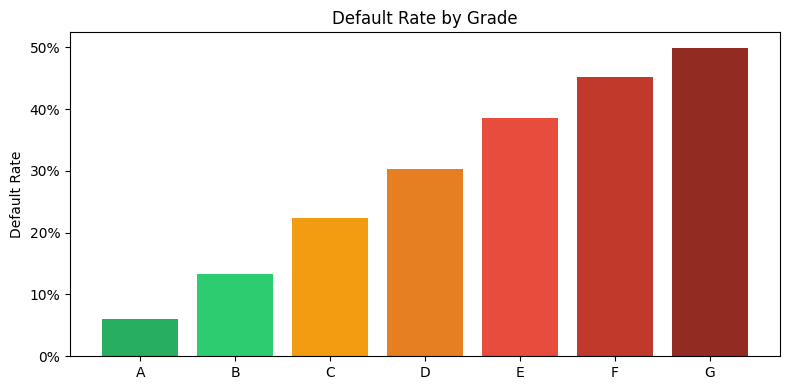

In [7]:
# Grade is the most important feature in credit scoring
# This confirms the ordinal relationship — higher grade = lower default rate
# If this pattern doesn't hold, something is wrong with the data

grade_map = {1:'A', 2:'B', 3:'C', 4:'D', 5:'E', 6:'F', 7:'G'}
grade_stats = df.groupby('grade_encoded').agg(
    count=('default_flag', 'count'),
    default_rate=('default_flag', 'mean')
).reset_index()
grade_stats['grade'] = grade_stats['grade_encoded'].map(grade_map)

print("Default rate by grade:")
print(grade_stats[['grade', 'count', 'default_rate']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(grade_stats['grade'], grade_stats['default_rate'],
       color=['#27ae60','#2ecc71','#f39c12','#e67e22','#e74c3c','#c0392b','#922b21'])
ax.set_title('Default Rate by Grade')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

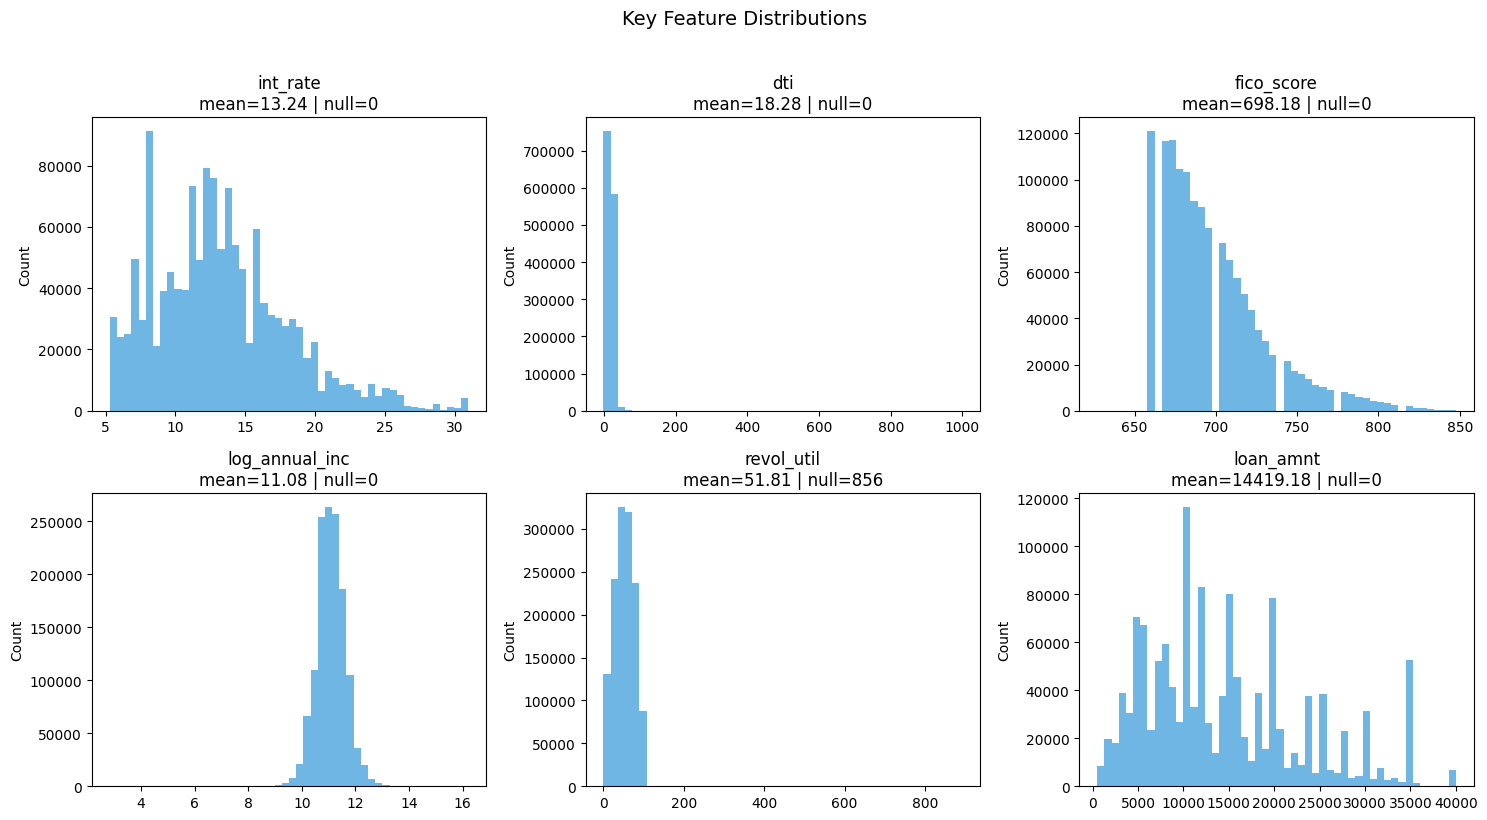

In [8]:
import numpy as np

# Check key numeric features for outliers and skew
# This informs preprocessing decisions in the training notebook
key_features = ['int_rate', 'dti', 'fico_score', 'log_annual_inc',
                'revol_util', 'loan_amnt']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(key_features):
    # Drop nulls for plotting only
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='#3498db', alpha=0.7, edgecolor='none')
    axes[i].set_title(f'{col}\nmean={data.mean():.2f} | null={df[col].isna().sum():,}')
    axes[i].set_ylabel('Count')

plt.suptitle('Key Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Identify which numeric features correlate most with default_flag
# High correlation = likely important for the model
# This is a quick signal — WoE/IV in the next notebook is more rigorous

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols
                if c not in ['default_flag', 'is_train', 'loan_id']]

correlations = df[numeric_cols + ['default_flag']]\
    .corr()['default_flag']\
    .drop('default_flag')\
    .abs()\
    .sort_values(ascending=False)

print("Top 15 features by correlation with default_flag:")
print(correlations.head(15).to_string())

Top 15 features by correlation with default_flag:
sub_grade_encoded       0.267261
grade_encoded           0.261537
int_rate                0.258827
term                    0.176126
fico_score              0.130703
acc_open_past_24mths    0.099878
dti                     0.084510
bc_open_to_buy          0.082051
avg_cur_bal             0.078938
tot_hi_cred_lim         0.078483
mort_acc                0.075310
total_bc_limit          0.072170
tot_cur_bal             0.071216
percent_bc_gt_75        0.067386
log_annual_inc          0.066317
